<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/03_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 03 — Naive Bayes Classifier (Department Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds a baseline Naive Bayes classifier to predict the assigned department from the request text.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

We load the train/test arrays saved from Notebook 02, rather than reprocessing the raw data again.

In [4]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_dept_train = np.load(f'{processed_dir}/y_dept_train.npy', allow_pickle=True)
y_dept_test = np.load(f'{processed_dir}/y_dept_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))
print("\nSample request texts:")
print(X_train[:5])

Training set size: 203501
Test set size: 50876

Sample request texts:
['Domestic Bulk Request' 'Unreported Flytipping Flytipping Team'
 'Smoke - Domestic Burning Pollution' 'Street Scene Flytipping Highway'
 'Rats Pest Control - Domestic']


## Converting text to numerical features using Bag of Words

Machine learning models need numbers, not text. We use CountVectorizer to convert each request into a vector representing word frequency — the same Bag of Words approach used in the NLP section of the course.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)
X_train_vec = cv.fit_transform(X_train).toarray()
X_test_vec = cv.transform(X_test).toarray()

print("Vocabulary size:", len(cv.vocabulary_))
print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Vocabulary size: 579
Training matrix shape: (203501, 579)
Test matrix shape: (50876, 579)


## Training the Naive Bayes model on the Training set

In [6]:
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(X_train_vec, y_dept_train)

MultinomialNB()

## Predicting the Test set results

In [7]:
y_pred = classifier.predict(X_test_vec)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_dept_test[:15]})
print(comparison)

Sample predictions vs actual:
                   Predicted                    Actual
0           Waste Management          Waste Management
1         Pollution Division        Pollution Division
2           Waste Management          Waste Management
3         Pollution Division        Pollution Division
4           Waste Management          Waste Management
5   Food and Safety Division  Food and Safety Division
6           Waste Management          Waste Management
7           Waste Management          Waste Management
8         Licensing Division        Licensing Division
9           Waste Management          Waste Management
10          Waste Management          Waste Management
11          Waste Management          Waste Management
12        Pollution Division        Pollution Division
13          Waste Management          Waste Management
14          Waste Management          Waste Management


## Making the Confusion Matrix

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_dept_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_dept_test, y_pred))

Confusion Matrix:
[[ 1166     2     5     7     3     0]
 [    0  2095     0     2     2     4]
 [    0     1  1590     3    11     0]
 [    0     8     0  6389     0     7]
 [    5     7     1     3   166     2]
 [    0     1     0    29     1 39366]]

Accuracy: 0.9979558141363315


In [9]:
print(classification_report(y_dept_test, y_pred))

                            precision    recall  f1-score   support

  Food and Safety Division       1.00      0.99      0.99      1183
          Housing Division       0.99      1.00      0.99      2103
        Licensing Division       1.00      0.99      0.99      1605
        Pollution Division       0.99      1.00      1.00      6404
Trading Standards Division       0.91      0.90      0.90       184
          Waste Management       1.00      1.00      1.00     39397

                  accuracy                           1.00     50876
                 macro avg       0.98      0.98      0.98     50876
              weighted avg       1.00      1.00      1.00     50876



## Visualising the Confusion Matrix

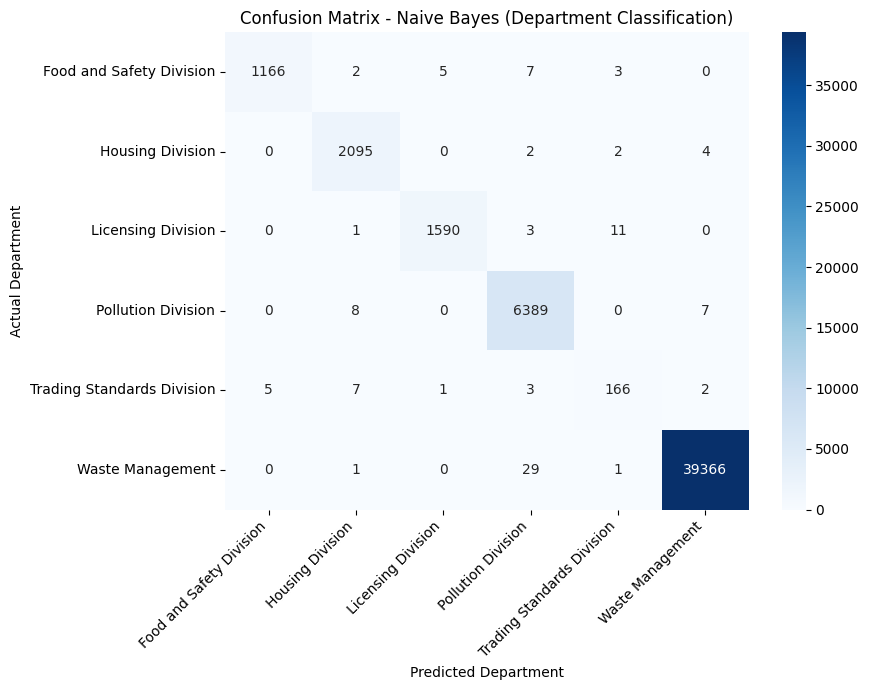

In [10]:
plt.figure(figsize=(9, 7))
labels = sorted(y_dept_test.tolist(), key=lambda x: list(y_dept_test).count(x), reverse=True)
unique_labels = sorted(set(y_dept_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Naive Bayes (Department Classification)')
plt.xlabel('Predicted Department')
plt.ylabel('Actual Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()